In [ ]:
!pip install optuna

In [ ]:
# Importing Libraties
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import optuna

In [ ]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/sklearn-ml-projects/Classfication_Projects/Platform_Trustworthiness/trustworthiness_dataset.csv')

In [ ]:
# Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   availability_score        10000 non-null  float64
 1   latency_variance          10000 non-null  float64
 2   throughput_score          10000 non-null  float64
 3   model_drift_score         10000 non-null  float64
 4   explainability_score      10000 non-null  float64
 5   fairness_index            10000 non-null  float64
 6   audit_failure_rate        10000 non-null  float64
 7   data_freshness_hours      10000 non-null  float64
 8   inference_cost_usd        10000 non-null  float64
 9   downtime_minutes_monthly  10000 non-null  int64  
 10  deployment_type           10000 non-null  object 
 11  model_category            10000 non-null  object 
 12  risk_assessment_level     10000 non-null  object 
 13  governance_status         10000 non-null  object 
 14  vendor_

,availability_score,latency_variance,throughput_score,model_drift_score,explainability_score,fairness_index,audit_failure_rate,data_freshness_hours,inference_cost_usd,downtime_minutes_monthly,trustworthiness_label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,84.824787,25.721964,550.045355,0.498713,0.647805,0.701887,0.150536,35.944162,1.007076,250.152400,0.903300
std,8.628904,14.175433,258.096382,0.288995,0.202499,0.173005,0.086297,20.589701,0.580390,143.980789,0.295564
min,70.000349,1.007729,100.043312,0.000006,0.300012,0.400005,0.000081,0.009361,0.010256,0.000000,0.000000
25%,77.389866,13.443344,328.373120,0.246857,0.470991,0.554174,0.076165,18.143885,0.495215,126.000000,1.000000
50%,84.775859,25.788942,551.861285,0.500030,0.645602,0.703654,0.151263,35.944664,1.013433,251.000000,1.000000
75%,92.200190,38.067482,770.206469,0.747116,0.825334,0.852068,0.225741,53.843184,1.520398,374.000000,1.000000
max,99.991530,49.996317,999.910879,0.999789,0.999981,0.999964,0.299907,71.991007,1.999984,499.000000,1.000000


In [ ]:
# Null Check
df.isnull().sum()

,0
availability_score,0
latency_variance,0
throughput_score,0
model_drift_score,0
explainability_score,0
fairness_index,0
audit_failure_rate,0
data_freshness_hours,0
inference_cost_usd,0
downtime_minutes_monthly,0


# Visualization (EDA)

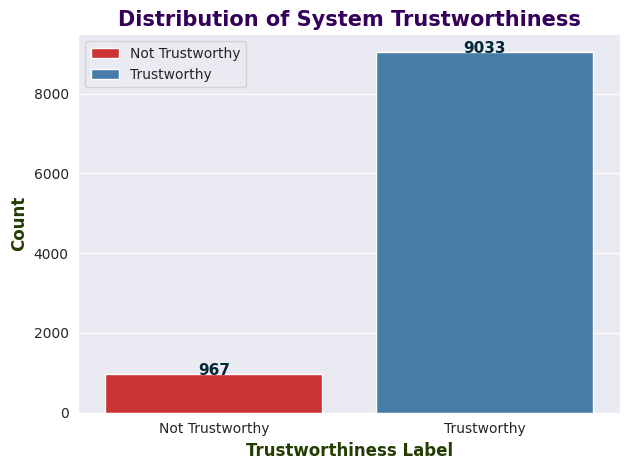

In [ ]:
# Page Theme
sns.set_style('darkgrid')

# Countplot
ax = sns.countplot(x='trustworthiness_label',data=df,hue='trustworthiness_label',palette='Set1')

# Annotation
for i in ax.patches:
    height = i.get_height()
    if height>0:
        plt.text(i.get_x()+i.get_width()/2,height+df.shape[0]*0.01,round(height),ha='center',va='center',fontsize=11,fontweight='bold',color='#002836')

# Styling Title and Labels
plt.title('Distribution of System Trustworthiness',fontsize=15,fontweight='bold',color='#340059')
plt.xlabel('Trustworthiness Label',fontsize=12,fontweight='bold',color='#233D00')
plt.ylabel('Count',fontsize=12,fontweight='bold',color='#233D00')
plt.xticks(ticks = [0,1],labels=['Not Trustworthy','Trustworthy'])
plt.legend(['Not Trustworthy','Trustworthy'])

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# The dataset shows significant class imbalance 90 to 10 ratio.
# Evaluation metrics beyond accuracy are necessary to ensure reliable detection of untrustworthy systems.

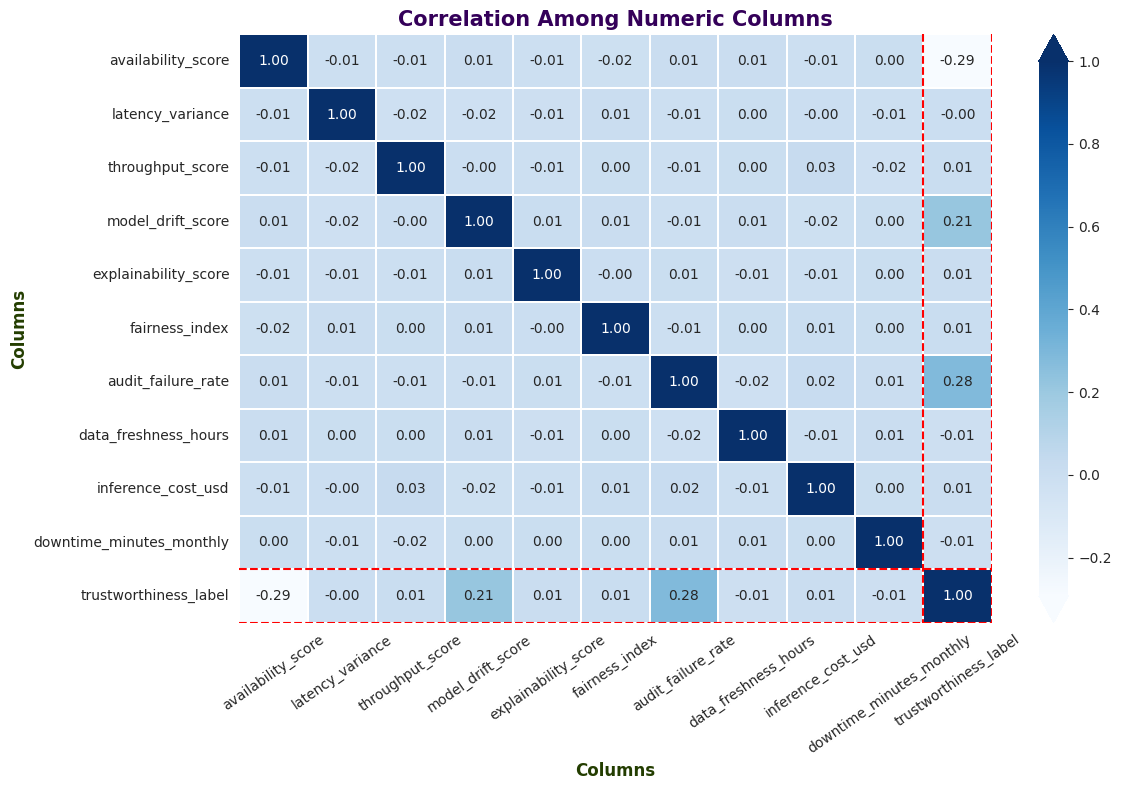

In [ ]:
# Plot Size
plt.figure(figsize=(12,8))

# Heatmap
num_cols = df.select_dtypes(exclude='object').columns.to_list()
target_idx = num_cols.index('trustworthiness_label')
relation = df[num_cols].corr()
c = {
    'shrink':1,
    'extend':'both'
    }
sns.heatmap(relation,annot=True,fmt='.2f',cmap='Blues',linewidth=0.1,cbar_kws=c)

# Annotation
plt.hlines(y=target_idx,xmin=0,xmax=len(num_cols),colors='r',linestyles='--')
plt.hlines(y=target_idx+1,xmin=0,xmax=len(num_cols),colors='r',linestyles='--')
plt.vlines(x=target_idx,ymin=0,ymax=len(num_cols),colors='r',linestyles='--')
plt.vlines(x=target_idx+1,ymin=0,ymax=len(num_cols),colors='r',linestyles='--')

# Styling Title and Labels
plt.title('Correlation Among Numeric Columns',fontsize=15,fontweight='bold',color='#340059')
plt.xlabel('Columns',fontsize=12,fontweight='bold',color='#233D00')
plt.ylabel('Columns',fontsize=12,fontweight='bold',color='#233D00')
plt.xticks(rotation=35)

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# Availability score shows strongest negative correlation (-0.29),
# while audit failure rate (0.28) and model drift (0.21) show positive correlation with system risk.
# No severe multicollinearity is observed, indicating stable feature structure for classification modeling.

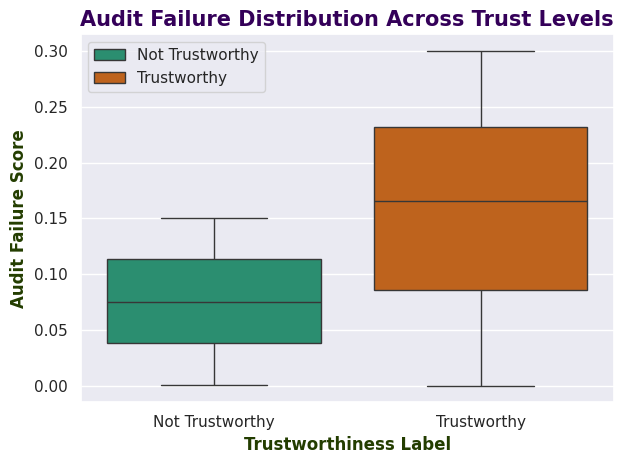

In [ ]:
# Page Theme
sns.set_theme(style='darkgrid')

# Boxplot
sns.boxplot(x='trustworthiness_label',y='audit_failure_rate',data=df,hue='trustworthiness_label',palette='Dark2')

# Styling Titles and Labels
plt.title('Audit Failure Distribution Across Trust Levels',fontsize=15,fontweight='bold',color='#340059')
plt.xlabel('Trustworthiness Label',fontsize=12,fontweight='bold',color='#233D00')
plt.ylabel('Audit Failure Score',fontsize=12,fontweight='bold',color='#233D00')
plt.xticks(ticks=[0,1],labels=['Not Trustworthy','Trustworthy'])
plt.legend(['Not Trustworthy','Trustworthy'])

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# Trustworthy systems exhibit higher audit failure rates in this dataset,
# Showing that audit failure alone does not determine system trustworthiness.

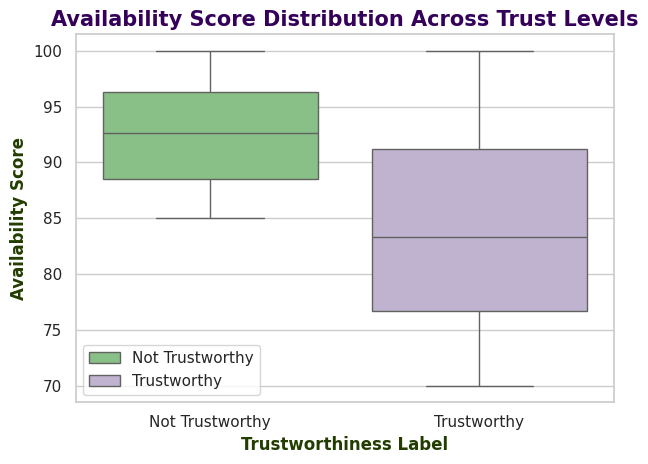

In [ ]:
# Page Theme
sns.set_theme(style='whitegrid')

# Boxplot
sns.boxplot(x='trustworthiness_label',y='availability_score',data=df,hue='trustworthiness_label',palette='Accent')

# Styling Titles and Labels
plt.title('Availability Score Distribution Across Trust Levels',fontsize=15,fontweight='bold',color='#340059')
plt.xlabel('Trustworthiness Label',fontsize=12,fontweight='bold',color='#233D00')
plt.ylabel('Availability Score',fontsize=12,fontweight='bold',color='#233D00')
plt.legend(['Not Trustworthy','Trustworthy'])
plt.xticks(ticks=[0,1],labels=['Not Trustworthy','Trustworthy'])

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Availability score alone does not determine system trustworthiness,
# as Not Trustworthy systems shows higher median availability in this dataset

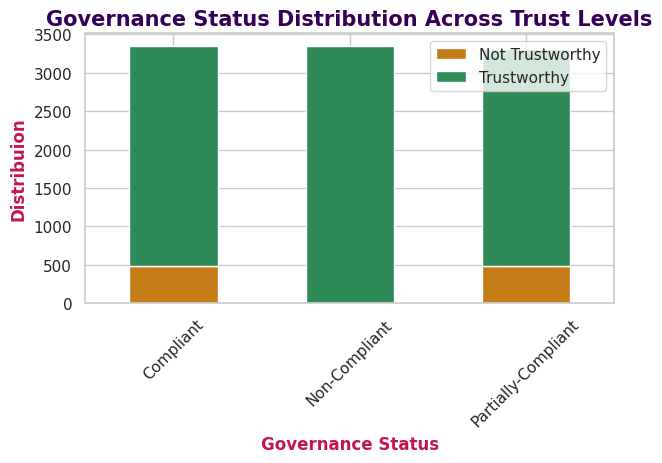

In [ ]:
# Bar-Stack plot
val = pd.crosstab(index=df['governance_status'],columns=df['trustworthiness_label'])
val.plot(kind='bar',stacked=True,color=['#C47C16','#2E8B57'])

# Styling Title and Labels
plt.title('Governance Status Distribution Across Trust Levels',fontsize=15,fontweight='bold',color='#340059')
plt.xlabel('Governance Status',fontsize=12,fontweight='bold',color='#C4164A')
plt.ylabel('Distribuion',fontsize=12,fontweight='bold',color='#C4164A')
plt.legend(['Not Trustworthy','Trustworthy'])
plt.xticks(rotation=45)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Governance status alone does not strongly differentiate trust levels,
# Indicates that system trustworthiness is determined by a combination of operations and risk related factors

# Feature Engineering

In [ ]:
avail_latency_ratio = df['availability_score']/df['latency_variance']
throughput_explain = df['throughput_score']*df['explainability_score']
freshness_explain_ratio = df['data_freshness_hours']/df['explainability_score']
downtime_audit = df['downtime_minutes_monthly']*df['audit_failure_rate']
fair_explain = df['fairness_index']*df['explainability_score']
cost_downtime = df['inference_cost_usd']*df['downtime_minutes_monthly']

df.insert(10,'avail_latency_ratio',avail_latency_ratio)
df.insert(11,'throughput_explain',throughput_explain)
df.insert(12,'freshness_explain_ratio',freshness_explain_ratio)
df.insert(13,'downtime_audit',downtime_audit)
df.insert(14,'fair_explain',fair_explain)
df.insert(15,'cost_downtime',cost_downtime)

#  Model Building

In [ ]:
independent = df.drop('trustworthiness_label',axis=1)
dependent = df['trustworthiness_label']
Xtrain,Xtest,ytrain,ytest = train_test_split(independent,dependent,train_size=0.8,random_state=55)
o_cols = independent.select_dtypes('object').columns.to_list()
n_cols = independent.select_dtypes(exclude='object').columns.to_list()
prep = ColumnTransformer([('encoding',OneHotEncoder(),o_cols),('scaling',StandardScaler(),n_cols)])
pipe = Pipeline([('prep',prep),('sampling',SMOTE(sampling_strategy='minority',k_neighbors=5,random_state=23)),('model',SVC())])

def best(trial):
    pipe.set_params(
        model__C = trial.suggest_int('C',1,8),
        model__degree = trial.suggest_int('degree',3,8),
        model__gamma = trial.suggest_float('gamma',1,5),
        model__kernel = trial.suggest_categorical('kernel',['linear','poly','rbf','sigmoid'])
    )
    score = cross_val_score(pipe,Xtrain,ytrain,cv=5,scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=34))
study.optimize(best,n_trials=15)
print(f'Best accuracy value = {study.best_value}')
print(f'Best accuracy value = {study.best_params}')

[I 2026-03-13 15:21:38,246] A new study created in memory with name: no-name-28a5c4b8-95f2-4e2f-a38a-c975bac9cc5a
[I 2026-03-13 15:22:43,245] Trial 0 finished with value: 0.8801331978333827 and parameters: {'C': 1, 'degree': 7, 'gamma': 1.3708150213365333, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8801331978333827.
[I 2026-03-13 15:24:14,760] Trial 1 finished with value: 0.8239667010794612 and parameters: {'C': 3, 'degree': 4, 'gamma': 2.6592985317470856, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8801331978333827.
[I 2026-03-13 15:24:45,988] Trial 2 finished with value: 0.9720704276265943 and parameters: {'C': 7, 'degree': 7, 'gamma': 2.086733334953206, 'kernel': 'linear'}. Best is trial 2 with value: 0.9720704276265943.
[I 2026-03-13 15:25:06,593] Trial 3 finished with value: 0.9720334992375619 and parameters: {'C': 4, 'degree': 6, 'gamma': 2.542302293038566, 'kernel': 'linear'}. Best is trial 2 with value: 0.9720704276265943.
[I 2026-03-13 15:26:43,614] Trial 4 finished w

Best accuracy value = 0.9720704276265943
Best accuracy value = {'C': 7, 'degree': 7, 'gamma': 2.086733334953206, 'kernel': 'linear'}


In [28]:
pipe.set_params(model__C= 7, model__degree= 7,model__kernel = 'linear')
model = pipe.fit(Xtrain,ytrain)

# Evaluation

In [29]:
pred = pipe.predict(Xtest)

# ---------------Accuracy Score----------------
acc_score = accuracy_score(ytest,pred)
print('Accuracy Score : ',acc_score)
# Overall model correctly classifies most samples, but accuracy alone is not sufficient due to class imbalance

# --------------Precision Score---------------
prec_score = precision_score(ytest,pred)
print('Precision Score : ',prec_score)
# High precision indicates that when model predicts the positive class,
# almost always correct, resulting in very low false positives.

# ---------------Recall Score--------------
re_score = recall_score(ytest,pred)
print('Recall Score : ',re_score)
# Good recall shows model correctly identifies almost all actual positive cases,
# indicating very few false negatives, which is crucial for imbalanced datasets.

# --------------f1 score------------
f1 = f1_score(ytest,pred)
print('f1 score : ',f1)
# High F1-score shows a strong balance between precision and recall,
# indicating a stable and reliable model

# ------------Classification Report-------------
report = classification_report(ytest,pred)
print(report)
# The classification report provides class-wise precision, recall, and F1-score,
# showing balanced performance across both classes

Accuracy Score :  0.896
Precision Score :  0.9877600979192166
Recall Score :  0.8956714761376249
f1 score :  0.9394644935972061
              precision    recall  f1-score   support

           0       0.49      0.90      0.63       198
           1       0.99      0.90      0.94      1802

    accuracy                           0.90      2000
   macro avg       0.74      0.90      0.79      2000
weighted avg       0.94      0.90      0.91      2000



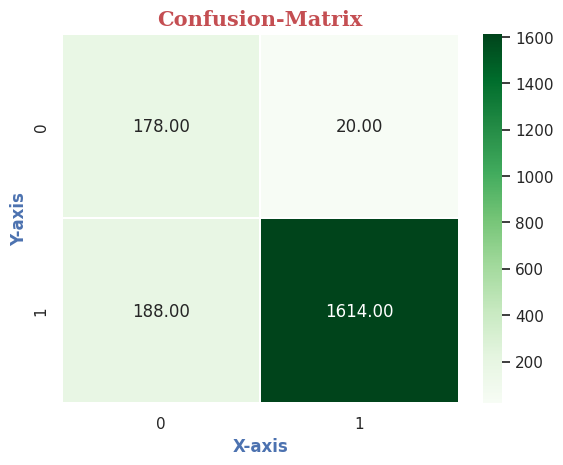

In [30]:
# -------------Confusion Matrix-------------
cms = confusion_matrix(ytest,pred)
sns.heatmap(cms,annot=True,fmt='.2f',cmap='Greens',linewidth=0.1)
plt.title('Confusion-Matrix',fontsize=15,fontweight='bold',color='r',fontfamily='Serif')
plt.xlabel('X-axis',fontsize=12,color='b',fontweight='bold')
plt.ylabel('Y-axis',fontsize=12,color='b',fontweight='bold')
plt.show()

# Insight
# True Negative - 178
# False Positive - 20
# False Negative - 188
# True Positive - 1614

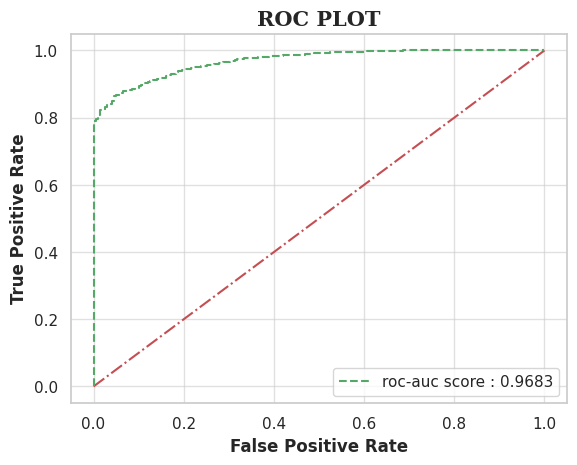

In [31]:
# ROC-Curve
values = pipe.decision_function(Xtest)
fpr,tpr,threshold = roc_curve(ytest,values)
roc_auc = roc_auc_score(ytest,values)
plt.plot([0,1],[0,1],color='r',linestyle='-.')
plt.plot(fpr,tpr,color='g',linestyle='--',label=f'roc-auc score : {round(roc_auc,4)}')
plt.title('ROC PLOT',fontsize=15,fontfamily='Serif',fontweight='bold')
plt.xlabel('False Positive Rate',fontsize=12,fontweight='bold')
plt.ylabel('True Positive Rate',fontsize=12,fontweight='bold')
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [33]:
# Saving Model
import joblib

joblib.dump(model,'Platform_Trust')


['Platform_Trust']